In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
data = pd.read_csv("preprocessed_data.csv")
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1.0,2.0,Graduate,No,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,Approved
1,2.0,0.0,Not Graduate,Yes,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,Rejected
2,3.0,3.0,Graduate,No,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,Rejected
3,4.0,3.0,Graduate,No,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5.0,5.0,Not Graduate,Yes,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [3]:
data.value_counts()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   float64
 1   no_of_dependents          4269 non-null   float64
 2   education                 4269 non-null   str    
 3   self_employed             4269 non-null   str    
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   float64
 7   cibil_score               4269 non-null   float64
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   str    
dtypes: float64(10), str(3)
memory usage: 433.7 KB


In [4]:
data["education"].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [5]:
data["education"] = data["education"].map({
    "Graduate" : 1,
    "Not Graduate" : 0

}
)

data["loan_status"] = data["loan_status"].map(
    {
        "Approved" : 1,
        "Rejected" : 0
    }

)



In [6]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1.0,2.0,1,No,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,1
1,2.0,0.0,0,Yes,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,0
2,3.0,3.0,1,No,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,0
3,4.0,3.0,1,No,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,0
4,5.0,5.0,0,Yes,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,0


In [7]:
#here one hot encoding is not required , but just coomenting the part
#which might be required in future when format of data is updated


'''cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)'''

cols = ["self_employed"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded = ohe.fit_transform(data[cols])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=data.index)
data = pd.concat([data.drop(columns=cols),encoded_df],axis=1)

<Axes: >

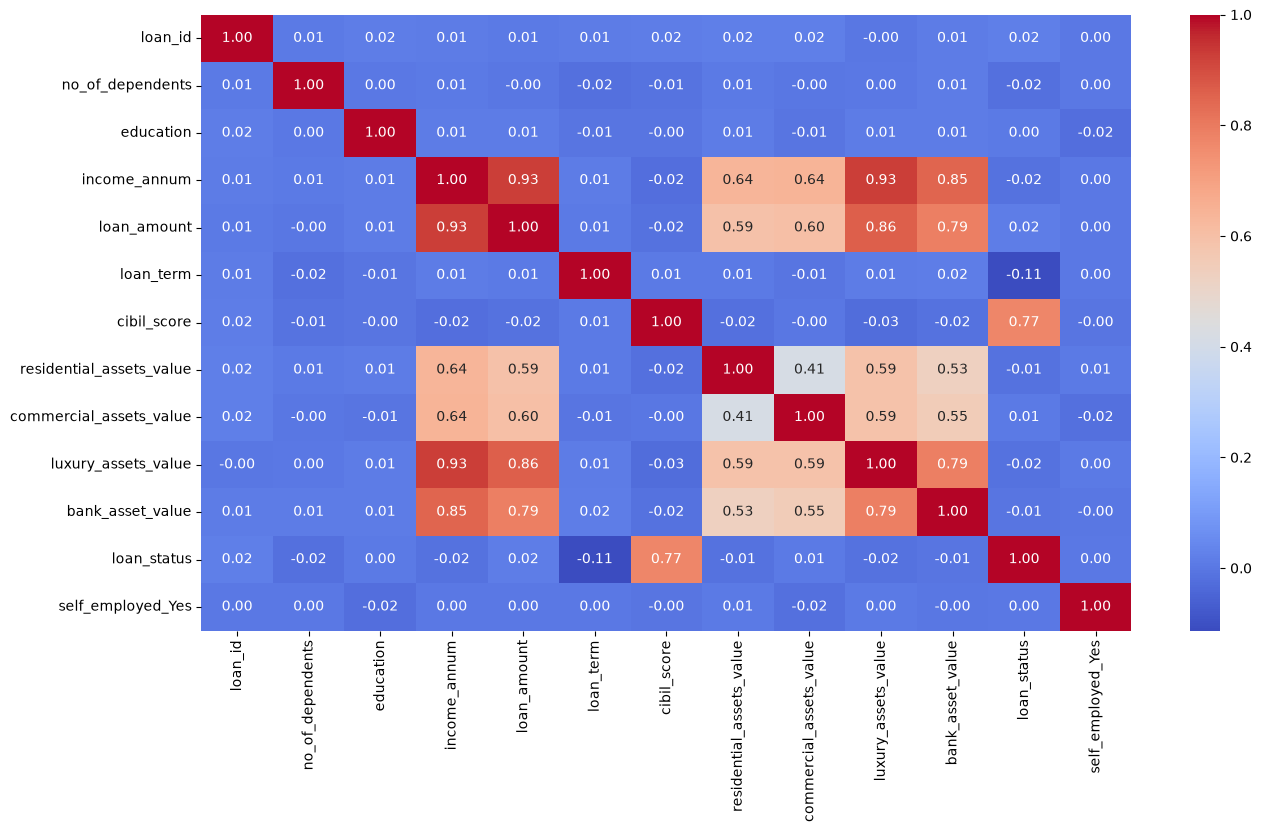

In [8]:
num_cols = data.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [9]:
#from viaulisation part , we can clearly see loan id has no use in predicting our model
# and other candidate for removals remain : no_of_dependents,education

In [10]:
data = data.drop(columns=["loan_id"])

In [11]:
data.head()

,no_of_dependents,education,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,self_employed_Yes
0,2.0,1,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,1,0.0
1,0.0,0,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,0,1.0
2,3.0,1,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,0,0.0
3,3.0,1,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,0,0.0
4,5.0,0,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,0,1.0


In [12]:
data.to_csv(r"preprocessed_encoded_data.csv", index=False)